In [1]:
import pandas as pd
import numpy as np

In [2]:
test_df = pd.read_csv('test.csv')
train_df = pd.read_csv('train.csv')

In [3]:
train_df.isnull().sum()

ImgId             0
title             1
description    1042
categories        0
dtype: int64

In [4]:
test_df.isnull().sum()

ImgId            0
title            1
description    218
dtype: int64

In [5]:
train_df = train_df.dropna(subset=["title"])
test_df = test_df.dropna(subset=["title"])

<Axes: xlabel='categories'>

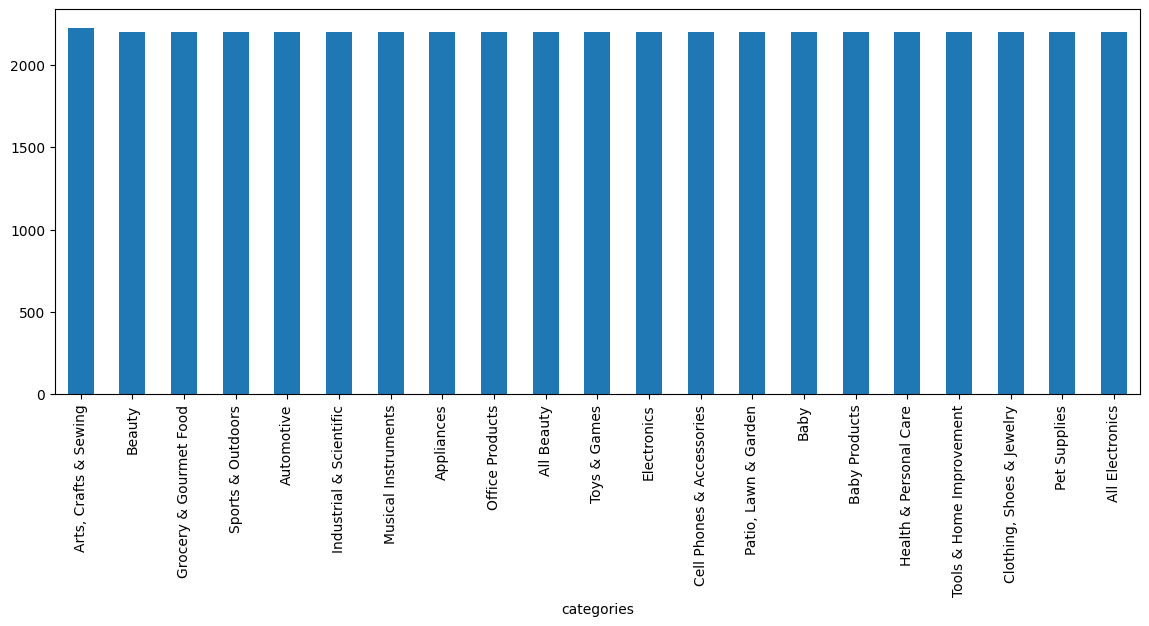

In [6]:
train_df['categories'].value_counts().plot(kind='bar',figsize=(14,5))

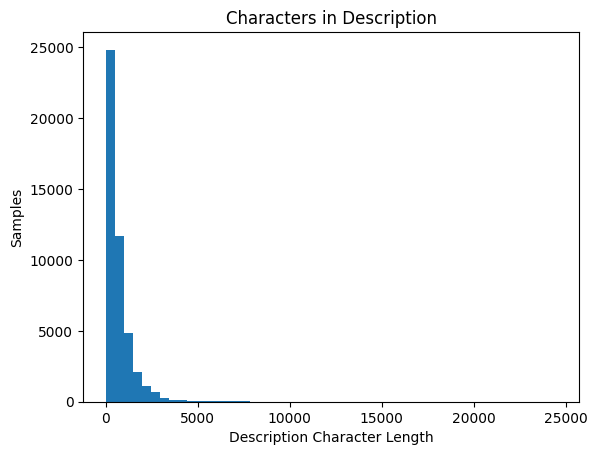

In [7]:
import matplotlib.pyplot as plt
word_len = train_df['description'].str.split().map(lambda x:len(str(x)))
plt.hist(word_len,bins=50)
plt.ylabel('Samples')
plt.xlabel('Description Character Length')
plt.title('Characters in Description')
plt.show()

In [8]:
import cv2
def load_images(df, folder):
    images = []
    valid_indices = []

    for idx, img_id in enumerate(df["ImgId"]):
        path = f"{folder}/{img_id}.jpg"

        img = cv2.imread(path)

        if img is None:
            # print("Could not load:", path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100,100))
        img = img.astype(np.float32)

        images.append(img)
        valid_indices.append(idx)

    return np.array(images), valid_indices

In [9]:
X_img_train, train_valid_idx = load_images(train_df, "train")
X_img_test, test_valid_idx = load_images(test_df, "test")

train_df = train_df.iloc[train_valid_idx].reset_index(drop=True)
test_df = test_df.iloc[test_valid_idx].reset_index(drop=True)

In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_train = le.fit_transform(train_df["categories"])

C:\Users\Akshat\anaconda3\envs\gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [11]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [12]:
test_df["text"] = test_df["title"] + " " + test_df["description"].fillna("")
train_df["text"] = train_df["title"] + " " + train_df["description"].fillna("")

In [13]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 30000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df["text"])

X_text_train = tokenizer.texts_to_sequences(train_df["text"])
X_text_test = tokenizer.texts_to_sequences(test_df["text"])

X_text_train = pad_sequences(X_text_train, maxlen=max_len)
X_text_test = pad_sequences(X_text_test, maxlen=max_len)

In [14]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [15]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Dense, BatchNormalization
)

image_input = Input(shape=(100, 100, 3), name="img")

# CNN feature extractor
x = Conv2D(32, (3, 3), activation="relu", padding="same")(image_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

# Feature vector
x = GlobalAveragePooling2D()(x)
image_features = Dense(256, activation="relu")(x)

In [16]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM

text_input = Input(shape=(max_len,),name="text")

text_branch = Embedding(
        input_dim=max_words,
        output_dim=128)(text_input)

text_branch = Bidirectional(
        LSTM(128))(text_branch)

text_branch = Dense(128, activation='relu')(text_branch)

In [17]:
from tensorflow.keras.layers import concatenate, Dropout
from tensorflow.keras import regularizers

combined = concatenate([image_features, text_branch])

combined = Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001))(combined)
combined = Dropout(0.5)(combined)

output = Dense(21, activation='softmax')(combined)

In [18]:
from tensorflow.keras.models import Model

model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [21]:
val_size = int(0.1 * len(X_img_train))

train_img = X_img_train[:-val_size]
val_img = X_img_train[-val_size:]

train_text = X_text_train[:-val_size]
val_text = X_text_train[-val_size:]

train_y = y_train[:-val_size]
val_y = y_train[-val_size:]

In [22]:
import tensorflow as tf

with tf.device('/CPU:0'):
    train_ds = tf.data.Dataset.from_tensor_slices((
        {
            "img": train_img,
            "text": train_text
        },
        train_y
    ))

    val_ds = tf.data.Dataset.from_tensor_slices((
        {
            "img": val_img,
            "text": val_text
        },
        val_y
    ))

train_ds = train_ds.shuffle(10000).batch(16).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(16).prefetch(tf.data.AUTOTUNE)

history = model.fit(train_ds , validation_data=val_ds, epochs=10, callbacks=[early_stop])

Epoch 1/10
2363/2363 [==============================] - 161s 61ms/step - loss: 2.5080 - accuracy: 0.2353 - val_loss: 1.8833 - val_accuracy: 0.3767
Epoch 2/10
2363/2363 [==============================] - 135s 57ms/step - loss: 1.4852 - accuracy: 0.5234 - val_loss: 1.2388 - val_accuracy: 0.6121
Epoch 3/10
2363/2363 [==============================] - 137s 58ms/step - loss: 0.9325 - accuracy: 0.7149 - val_loss: 1.1077 - val_accuracy: 0.6895
Epoch 4/10
2363/2363 [==============================] - 136s 58ms/step - loss: 0.6028 - accuracy: 0.8258 - val_loss: 0.9145 - val_accuracy: 0.7693
Epoch 5/10
2363/2363 [==============================] - 138s 58ms/step - loss: 0.4098 - accuracy: 0.8914 - val_loss: 0.9821 - val_accuracy: 0.7607
Epoch 6/10
2363/2363 [==============================] - 136s 58ms/step - loss: 0.2849 - accuracy: 0.9285 - val_loss: 1.0759 - val_accuracy: 0.7788
Epoch 7/10
2363/2363 [==============================] - 138s 58ms/step - loss: 0.2094 - accuracy: 0.9516 - val_loss: 1

In [26]:
model.save("model.keras")

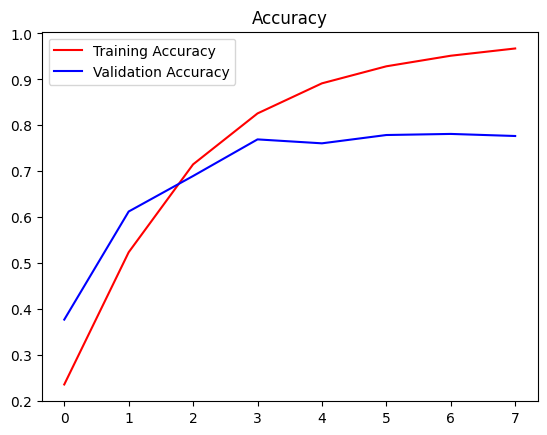

<Figure size 640x480 with 0 Axes>

In [27]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))
plt.plot(epochs,acc,'r',label = 'Training Accuracy')
plt.plot(epochs,val_acc,'b',label = 'Validation Accuracy')
plt.title('Accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

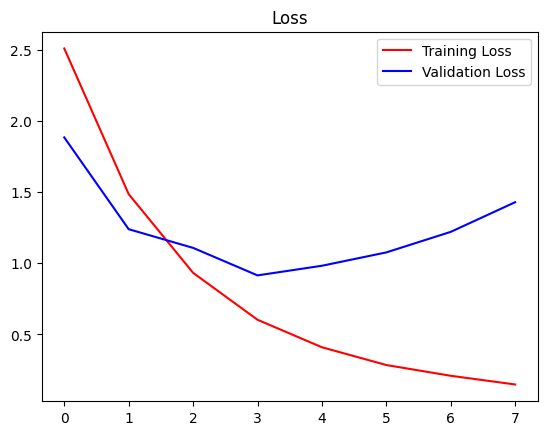

<Figure size 640x480 with 0 Axes>

In [28]:
plt.plot(epochs,loss,'r',label = 'Training Loss')
plt.plot(epochs,val_loss,'b',label = 'Validation Loss')
plt.title('Loss')
plt.legend(loc=0)
plt.figure()
plt.show()